# 02 - Preprocessing: Bank Marketing Dataset

## Bước 3 trong khung 8 bước: Tiền xử lý

In [3]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocess import (
    load_data, clean_data, normalize_numeric, encode_onehot, export_p,
    numeric_cols, categorical_cols, raw_path, out_path, out_version_path
)

%matplotlib inline
sns.set_style('whitegrid')

### A. Load dữ liệu gốc

In [4]:
raw = load_data(raw_path)
print('Kích thước:', raw.shape)
raw.head()

Kích thước: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### B. Data Cleaning
`clean_data()` thực hiện:
1. `drop_duplicates()` — loại dòng trùng lặp
2. `rename()` — đổi tên cột (`y → subscribed`, bỏ dấu `.` trong tên cột)
3. `replace()` — chuẩn hóa nhãn `yes/no → 1/0`
4. Giữ `'unknown'` làm 1 category riêng
5. Xử lý `NaN` thật (nếu có) bằng mode (categorical) / median (numeric)
6. Loại dòng `duration == 0`
7. `astype()` — ép kiểu dữ liệu

In [9]:
clean_df, clean_log = clean_data(raw)

print('=== CLEANING LOG ===')
for k, v in clean_log.items():
    print(f'{k}: {v}')


=== CLEANING LOG ===
duplicates_removed: 12
cate_missing_filled: {}
keep_unknown: {'job': 330, 'marital': 80, 'education': 1730, 'default': 8596, 'housing': 990, 'loan': 990}
nume_missing_filled: {}
fully_empty: 0
duration_new: 4
rows_before: 41188
rows_after: 41172


In [10]:
clean_df.head()

# xác nhận không còn NaN
clean_df.isna().sum().sum()

np.int64(0)

### C. Data Transformation — Chuẩn hóa (Normalization)
Dùng Z-score cho các cột số (trừ `age`, `duration`)

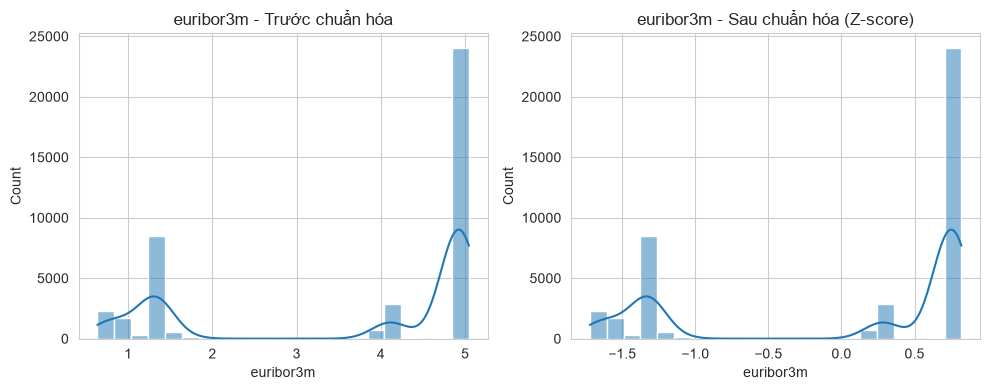

In [6]:
numeric_cols_scaled = [c.replace('.', '_') for c in numeric_cols
                        if c not in ('age', 'duration')]

normalized_df = normalize_numeric(clean_df, numeric_cols_scaled)

# So sánh trước/sau chuẩn hóa
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(clean_df['euribor3m'], ax=ax1, kde=True)
ax1.set_title('euribor3m - Trước chuẩn hóa')

sns.histplot(normalized_df['euribor3m'], ax=ax2, kde=True)
ax2.set_title('euribor3m - Sau chuẩn hóa (Z-score)')

plt.tight_layout()

### D. Data Transformation — Mã hóa (Encoding)
One-Hot Encoding (`get_dummies`, `drop_first=True` để tránh đa cộng tuyến) cho
các biến phân loại.

In [7]:
final_df = encode_onehot(normalized_df, categorical_cols)

print('Trước encode:', normalized_df.shape[1], 'cột')
print('Sau encode:', final_df.shape[1], 'cột')
final_df.head()

Trước encode: 21 cột
Sau encode: 54 cột


,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261.0,-0.565904,0.195451,-0.349566,0.648071,0.72257,0.886551,0.712431,0.331668,...,True,False,False,False,True,False,False,False,True,False
1,57,149.0,-0.565904,0.195451,-0.349566,0.648071,0.72257,0.886551,0.712431,0.331668,...,True,False,False,False,True,False,False,False,True,False
2,37,226.0,-0.565904,0.195451,-0.349566,0.648071,0.72257,0.886551,0.712431,0.331668,...,True,False,False,False,True,False,False,False,True,False
3,40,151.0,-0.565904,0.195451,-0.349566,0.648071,0.72257,0.886551,0.712431,0.331668,...,True,False,False,False,True,False,False,False,True,False
4,56,307.0,-0.565904,0.195451,-0.349566,0.648071,0.72257,0.886551,0.712431,0.331668,...,True,False,False,False,True,False,False,False,True,False


### E. Xuất file (Output) + ghi Version

In [8]:
export_p(
    final_df, out_path, out_version_path, clean_log,
    extra_notes='Numeric (trừ age/duration) chuẩn hóa Z-score; categorical one-hot drop_first=True.'
)

print('Đã lưu:', out_path)
print('Version info:', out_version_path)

Đã lưu: ../data/processed/bank-clean.csv
Version info: ../data/processed/version_info.json
